# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习 
- 设计题目：基于BiLSTM与BERT的中文新闻文本情感倾向分析研究
- 姓    名：罗靓
- 学    号：20234080407  
- 班    级：本23数据04班  
- 指导教师：丁平尖
- 提交日期：2026年6月17日

## 二、摘要

随着媒体行业的快速发展，海量新闻文本蕴含着丰富的情感倾向与舆论导向信息，对舆情监测、社会情绪分析具有重要意义。传统情感分类方法在处理新闻文本的长句、书面化表达与含蓄情感时存在局限，本研究以公开中文新闻文本情感数据集为对象，构建BiLSTM与BERT两种模型开展情感倾向分析任务。通过数据清洗、分词与序列截断等预处理流程，对比分析两种模型在情感极性（正面/负面/中性）分类上的性能差异。实验结果表明，BERT模型凭借预训练语言理解能力，在捕捉新闻文本的深层语义与含蓄情感上表现更优，准确率、F1 值均显著高于BiLSTM模型。本研究为新闻文本情感分析提供了模型选型参考，对舆情监测与内容分析具有实践意义。

## 三、问题定义与需求分析

### 3.1 项目背景与意义
随着互联网技术的快速发展，新闻媒体已成为公众获取信息、表达观点的主要渠道之一，海量的新闻文本数据中蕴含着丰富的情感倾向与舆论导向信息。这些信息不仅反映了公众对社会事件的态度，也对舆情监测、政策制定、内容推荐等应用场景具有重要的参考价值。然而，传统人工分析方式难以应对海量数据，且效率低、主观性强，无法满足实时舆情监测的需求。
自然语言处理技术的发展为解决这一问题提供了有效途径，其中文本情感分类技术能够自动识别文本的情感极性，实现对大规模新闻数据的快速分析。本研究以深度学习方法为基础，对比 BiLSTM 与 BERT 模型在中文新闻文本情感分类任务中的表现，探究不同模型对新闻文本的适配性，为舆情监测系统的模型选型提供参考，同时深化对深度学习技术在自然语言处理领域应用的理解，具有一定的实际应用价值与科研意义。

### 3.2 问题描述

> 输入输出定义  
输入：单条中文新闻文本数据，包含新闻标题与正文内容，为非结构化的中文文本序列。
输出：该新闻文本对应的情感极性标签，分为三类：0（负面情感）、1（中性情感）、2（正面情感）。
> 任务类型  
本项目属于多分类文本情感分类任务，核心目标是构建深度学习模型，自动学习新闻文本中的情感特征，实现对文本情感极性的精准预测。
> 预期性能指标
本项目采用以下指标对模型性能进行评估：
准确率（Accuracy）：模型预测正确的样本数占总样本数的比例，预期达到 80% 以上。
精确率（Precision）：模型预测为某一类别的样本中，真实属于该类别的比例，预期各类别精确率均不低于 75%。
召回率（Recall）：真实属于某一类别的样本中，被模型正确预测的比例，预期各类别召回率均不低于 75%。
F1 值：精确率与召回率的调和平均数，综合反映模型的分类性能，预期整体 F1 值不低于 0.78。
对比性能：深度学习模型（BiLSTM、BERT）的性能需显著优于传统机器学习基线模型（如朴素贝叶斯），预期准确率提升幅度不低于 10%。

## 四、数据集说明与预处理

### 4.1 数据来源与规模


本研究采用公开中文新闻文本情感数据集，由两部分文件组成：文本文件Train_DataSet.csv、标签文件Train_DataSet_Label.csv及测试文件Test_DataSet.csv。通过id字段将文本与标签进行关联，形成完整的带标注数据集。
首先导入所需库（PyTorch、sklearn、jieba、matplotlib 等），设置随机种子以保证实验可复现性。随后读取训练集文本文件、标签文件和测试集文件，通过 id 字段关联合并训练数据。


In [1]:
import numpy as np
import pandas as pd
import re
import os
import random
import jieba
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

train_data = pd.read_csv('Train_DataSet.csv')
train_labels = pd.read_csv('Train_DataSet_Label.csv')
test_data = pd.read_csv('Test_DataSet.csv')
train_df = pd.merge(train_data, train_labels, on='id')
print(f"训练集: {train_df.shape}, 测试集: {test_data.shape}")
display(train_df.head())

PyTorch: 2.4.1+cpu, CUDA: False
训练集: (7340, 4), 测试集: (7356, 3)


,id,title,content,label
0,7a3dd79f90ee419da87190cff60f7a86,问责领导(上黄镇党委书记张涛，宣国才真能一手遮天吗？),这几天看了有人举报施某某的贴子，经与举报人联系证实，是宣某当天中午请举报人和枪手喝酒后，晚上...,2
1,7640a5589bc7486ca199eeeb38af79dd,江歌事件:教会孩子，善良的同时更要懂得保护自己!,过去一年的江歌悲剧，这几日再次刷屏：住在东京都中野区的中国女留学生江歌，收留了被前男友陈世锋...,1
2,8c5bda93e4ba401f90a0faa5b28fe57f,"绝味鸭脖广告""开黄腔""引众怒 ""双11""这么拼值吗?",“双11”1600亿的销售额让中国乃至全世界感到震惊，为此，不仅有不惜欠债百万的“剁手党”，...,2
3,1aa777fed31a4b8a9d866f05b5477557,央视曝光!如东一医药企业将槽罐车改成垃圾车，夜间偷排高浓度废水,2016年以来，如东高新区一家叫做拜瑞生物医药的企业竟然将装废水的槽罐车伪装成洒水车，常年在...,2
4,6c67ac55360340258e157f3710ebae6c,恶劣至极，央视都曝光了!南通如东一医药企业将槽罐车改成洒水车，夜间偷排高浓度废水...丢大发了!,新闻资讯•民生热点•城市生活•南通人都在看浏览更多资讯请关注微信公众号:南通传媒网昨晚央视一...,2


合并后的训练集共包含 7340 条样本，包含 id、title、content、label 四列；测试集包含 7356 条样本，不含 label 列，用于最终提交预测结果。从预览数据可以看出，title 列为新闻标题，content 列为新闻正文内容，label 为三分类情感标签（0=负面、1=中性、2=正面）。部分样本的正文内容较长，且存在夹杂 HTML 标签的现象，需在后续预处理中进行清洗。

> 样本总量  
合并后的训练集共包含 7340 条样本，测试集包含 7356 条无标注样本。经检查，训练集中 title 列存在 1 条缺失值，content 列存在 71 条缺失值，需在后续预处理阶段进行填充或剔除处理，以避免影响模型训练。


In [2]:
print(f"训练集: {len(train_df)}条")
print(f"测试集: {len(test_data)}条")
print(f"缺失值:\n{train_df.isnull().sum()}")
print(f"数据类型:\n{train_df.dtypes}")

训练集: 7340条
测试集: 7356条
缺失值:
id          0
title       1
content    71
label       0
dtype: int64
数据类型:
id         object
title      object
content    object
label       int64
dtype: object



> 类别分布

数据集中情感标签分为三类，分布情况如下：
标签 0（负面情感）：763 条，占比约 10.4%
标签 1（中性情感）：3646 条，占比约 49.7%
标签 2（正面情感）：2931 条，占比约 39.9%
整体数据分布存在轻微不平衡现象，中性情感样本数量较多，负面情感样本数量较少，后续将通过数据划分与模型训练策略缓解不平衡带来的影响。

标签0(负面): 763条, 10.4%
标签1(中性): 3646条, 49.7%
标签2(正面): 2931条, 39.9%


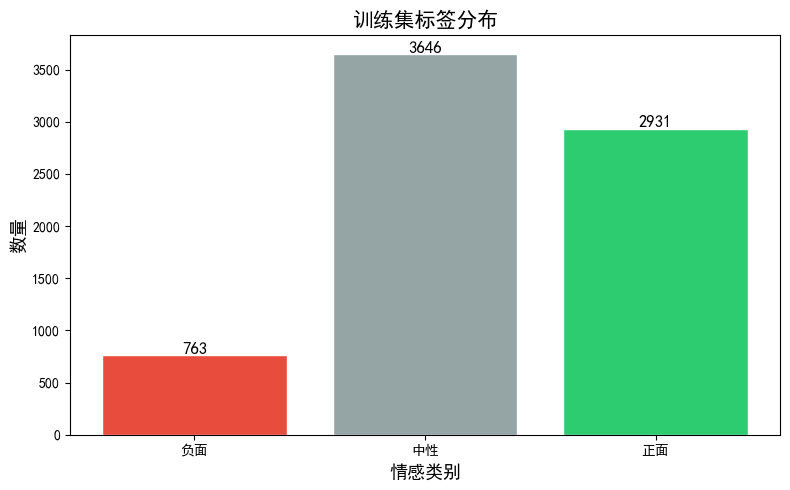

In [3]:
label_map = {0: '负面', 1: '中性', 2: '正面'}
label_counts = train_df['label'].value_counts().sort_index()
for k, v in label_map.items():
    c = label_counts.get(k, 0)
    print(f"标签{k}({v}): {c}条, {c/len(train_df)*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([label_map[x] for x in label_counts.index], label_counts.values,
              color=['#e74c3c','#95a5a6','#2ecc71'], edgecolor='white')
ax.set_xlabel('情感类别', fontsize=13)
ax.set_ylabel('数量', fontsize=13)
ax.set_title('训练集标签分布', fontsize=15)
for bar, val in zip(bars, label_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15, str(val), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

### 4.2 数据探索

> 样本示例 

In [4]:
for lv in [0, 1, 2]:
    s = train_df[train_df['label']==lv].iloc[0]
    print(f"【{label_map[lv]}】标题: {s['title'][:60]}")
    print(f"  正文: {str(s['content'])[:120]}...\n")

【负面】标题: 太仓立案查处42起药械违法行为 保障百姓用药安全
  正文: （原标题：保障百姓吃对药就好医 太仓立案查处42起药械违法行为）城乡结合部及农村地区的小药店小诊所点多面广，且直接面向基层老百姓。为了进一步加强药品和医疗器械质量监管，今年7月—10月，太仓市市场监督管理局开展了城乡结合部和农村地区药店诊所...

【中性】标题: 江歌事件:教会孩子，善良的同时更要懂得保护自己!
  正文: 过去一年的江歌悲剧，这几日再次刷屏：住在东京都中野区的中国女留学生江歌，收留了被前男友陈世锋恶意纠缠的闺蜜刘鑫，两人在回到江歌公寓楼时，陈世锋已经等在楼下，叫嚣着要刘鑫给自己一个说法（男友此时的情绪处于濒临崩溃的状态）。江歌为了保护刘鑫，就...

【正面】标题: 问责领导(上黄镇党委书记张涛，宣国才真能一手遮天吗？)
  正文: 这几天看了有人举报施某某的贴子，经与举报人联系证实，是宣某当天中午请举报人和枪手喝酒后，晚上才发的贴子！ 本人不去讨论前二天的举报，相信总归会有说法的！ 今天一看施全军2017年1月2日实名举报上黄镇宣国才的贴子（仍被锁定禁止评论）已经正好...



从训练集中分别抽取负面、中性、正面三类各一条样本进行展示。可以看到，每条数据由标题（title）和正文（content）两部分组成，标题通常为新闻标题，正文为新闻内容摘要。三类样本在内容风格上存在差异：负面样本多涉及问题曝光与违规查处，中性样本以客观事件报道为主，正面样本则偏向舆论监督与问责类内容。通过样本预览可以直观了解数据的基本结构和文本特征，为后续的预处理和建模提供参考。

 
> 统计分布  

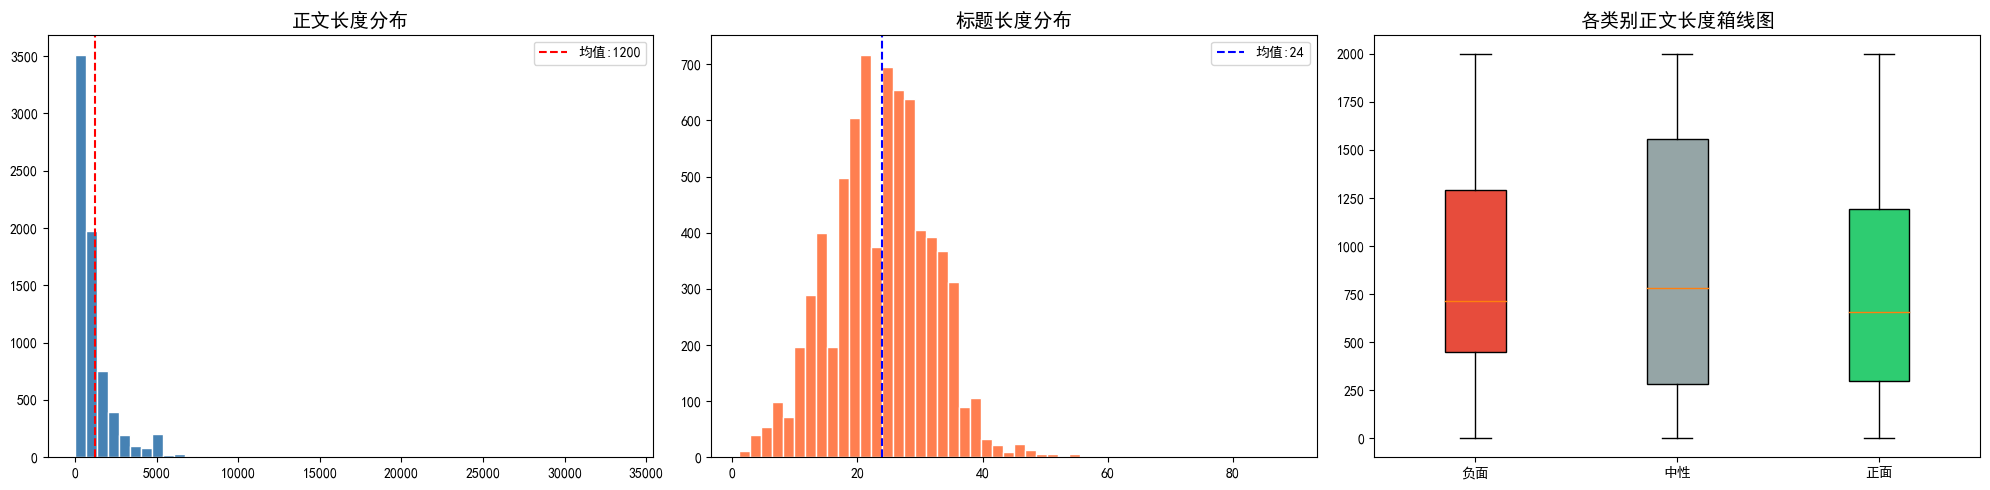

In [5]:
train_df['title_len'] = train_df['title'].astype(str).apply(len)
train_df['content_len'] = train_df['content'].astype(str).apply(len)
train_df['total_len'] = train_df['title_len'] + train_df['content_len']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].hist(train_df['content_len'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(train_df['content_len'].mean(), color='red', linestyle='--',
                label=f'均值:{train_df["content_len"].mean():.0f}')
axes[0].set_title('正文长度分布', fontsize=14)
axes[0].legend()

axes[1].hist(train_df['title_len'], bins=50, color='coral', edgecolor='white')
axes[1].axvline(train_df['title_len'].mean(), color='blue', linestyle='--',
                label=f'均值:{train_df["title_len"].mean():.0f}')
axes[1].set_title('标题长度分布', fontsize=14)
axes[1].legend()

box_data = [train_df[train_df['label']==lv]['content_len'].clip(upper=2000).values for lv in [0,1,2]]
bp = axes[2].boxplot(box_data, labels=[label_map[i] for i in [0,1,2]], patch_artist=True)
for patch, c in zip(bp['boxes'], ['#e74c3c','#95a5a6','#2ecc71']):
    patch.set_facecolor(c)
axes[2].set_title('各类别正文长度箱线图', fontsize=14)
plt.tight_layout()
plt.show()

对训练集中标题长度和正文长度进行统计分析。正文长度均值约为 1200 字，大部分样本集中在 500~3000 字之间，少量极端样本超过 10000 字；标题长度均值约为 24 字，主要分布在 10~40 字之间。从各类别正文长度箱线图来看，负面、中性、正面三类样本的正文长度中位数相近，但正面和负面样本的离散程度略大，存在较多长文本离群点。整体来看，文本长度分布存在右偏现象，后续建模时需要对长文本进行截断处理，以适应模型的输入长度限制。

> 相关性分析


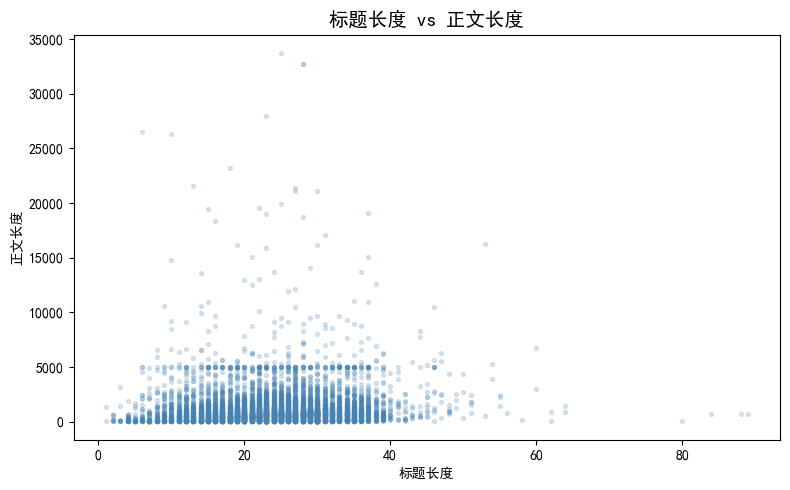

Pearson相关系数: 0.0746


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(train_df['title_len'], train_df['content_len'], alpha=0.2, s=8, c='steelblue')
ax.set_xlabel('标题长度')
ax.set_ylabel('正文长度')
ax.set_title('标题长度 vs 正文长度', fontsize=14)
plt.tight_layout()
plt.show()
print(f"Pearson相关系数: {train_df['title_len'].corr(train_df['content_len']):.4f}")

通过散点图探究标题长度与正文长度之间的相关性。使用 matplotlib 绘制两者的一一对应关系，并计算 Pearson 相关系数量化线性相关程度。结果显示，Pearson 相关系数仅为 0.0746，标题长度与正文长度几乎不存在线性相关，即标题的长短无法反映正文的篇幅长短。数据点主要集中在标题长度 10~40 字、正文长度 5000 字以内的区域，同时存在少量正文超过 30000 字的极端样本。这一分析表明，标题和正文携带的信息维度相对独立，在后续建模中可考虑将标题与正文分别处理或拼接使用，以充分利用两者的互补信息。


### 4.3 预处理流程

> 清洗  


In [7]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'window\.open\([^)]*\)', '', text)
    text = re.sub(r'onload="[^"]*"', '', text)
    text = re.sub(r'src="[^"]*"', '', text)
    text = re.sub(r'style="[^"]*"', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['text'] = train_df['title'].astype(str) + '。' + train_df['content'].astype(str)
test_data['text'] = test_data['title'].astype(str) + '。' + test_data['content'].astype(str)

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_data['clean_text'] = test_data['text'].apply(clean_text)

print("清洗前后对比:")
print(f"前: {train_df['text'].iloc[2][:120]}")
print(f"后: {train_df['clean_text'].iloc[2][:120]}")

# 换一个脏数据多的样本看清洗效果
idx = 0
print(f"===== 清洗前后对比(第{idx+1}条) =====")
print(f"清洗前:\n{train_df['text'].iloc[idx][:300]}")
print(f"\n清洗后:\n{train_df['clean_text'].iloc[idx][:300]}")

清洗前后对比:
前: 绝味鸭脖广告"开黄腔"引众怒 "双11"这么拼值吗?。“双11”1600亿的销售额让中国乃至全世界感到震惊，为此，不仅有不惜欠债百万的“剁手党”，更有绞尽脑汁吸引消费者的商家。就在“双11”前的11月1日，绝味鸭脖在其天猫旗舰店上，推出了一
后: 绝味鸭脖广告"开黄腔"引众怒 "双11"这么拼值吗?。“双11”1600亿的销售额让中国乃至全世界感到震惊，为此，不仅有不惜欠债百万的“剁手党”，更有绞尽脑汁吸引消费者的商家。就在“双11”前的11月1日，绝味鸭脖在其天猫旗舰店上，推出了一
===== 清洗前后对比(第1条) =====
清洗前:
问责领导(上黄镇党委书记张涛，宣国才真能一手遮天吗？)。这几天看了有人举报施某某的贴子，经与举报人联系证实，是宣某当天中午请举报人和枪手喝酒后，晚上才发的贴子！ 本人不去讨论前二天的举报，相信总归会有说法的！ 今天一看施全军2017年1月2日实名举报上黄镇宣国才的贴子（仍被锁定禁止评论）已经正好一整年了 =750) window.open('http://img.jsly001.com/attachment/mon_1801/4_291085_c796a6a86e17121.jpg?123');" onload="if(this.offsetwidth>'750')this.width='75

清洗后:
问责领导(上黄镇党委书记张涛，宣国才真能一手遮天吗？)。这几天看了有人举报施某某的贴子，经与举报人联系证实，是宣某当天中午请举报人和枪手喝酒后，晚上才发的贴子！ 本人不去讨论前二天的举报，相信总归会有说法的！ 今天一看施全军2017年1月2日实名举报上黄镇宣国才的贴子（仍被锁定禁止评论）已经正好一整年了 =750) this.width='750';" max-width:750px;"/>图片:/home/alidata/www/data/tmp/qfupload/4_291085_1514981471478952.jpg 施全军实名举报50天后，上黄镇党委政府回复如下图： =750) th


本步骤对原始文本进行预处理清洗。定义 clean_text 函数，利用正则表达式依次去除 HTML 标签、网页链接、邮箱地址、JavaScript 脚本代码（如 window.open、onload 等）以及多余空白字符，提取纯净的中文文本内容。将清洗后的结果分别存入训练集和测试集的 clean_text 列。通过抽样对比清洗前后的文本（如第 2 条和第 300 条样本），可以看到原始文本中夹杂的 HTML 标签和网页代码被有效去除，保留了可读的正文内容。文本清洗是 NLP 建模的重要前置步骤，干净的输入文本有助于模型更准确地学习语义特征，减少噪声干扰。

> 标注  

In [8]:
print("标签编码: 0→负面, 1→中性, 2→正面")
print(f"标签类型: {train_df['label'].dtype}")
print(f"唯一值: {sorted(train_df['label'].unique())}")
print(train_df['label'].value_counts().sort_index())

标签编码: 0→负面, 1→中性, 2→正面
标签类型: int64
唯一值: [0, 1, 2]
label
0     763
1    3646
2    2931
Name: count, dtype: int64


对标签列进行编码确认。训练集的 label 列已完成数值化编码：0 代表负面情感，1 代表中性情感，2 代表正面情感，数据类型为 int64，共 3 个唯一值，满足模型训练的输入要求。从各类别样本量来看，负面 763 条、中性 3646 条、正面 2931 条，进一步印证了前面标签分布分析中发现的类别不平衡现象。标签编码的正确性是模型训练的基础前提，确认无误后可直接用于后续模型输入。

> 归一化  

In [9]:
from collections import Counter

all_words = []
for text in train_df['clean_text']:
    all_words.extend([w for w in jieba.lcut(text) if w.strip()])

word_freq = Counter(all_words)
vocab = {w: i+2 for i, (w, f) in enumerate(word_freq.most_common()) if f >= 5}
vocab['<PAD>'], vocab['<UNK>'] = 0, 1
VOCAB_SIZE = len(vocab)
print(f"词汇表大小: {VOCAB_SIZE}")
print(f"Top10高频词: {word_freq.most_common(10)}")

MAX_LEN = 128
def text_to_seq(text, vocab, max_len):
    words = [w for w in jieba.lcut(clean_text(text)) if w.strip()][:max_len]
    seq = [vocab.get(w, 1) for w in words]
    return seq + [0] * (max_len - len(seq))

train_seqs = train_df['clean_text'].apply(lambda x: text_to_seq(x, vocab, MAX_LEN)).tolist()
test_seqs = test_data['clean_text'].apply(lambda x: text_to_seq(x, vocab, MAX_LEN)).tolist()

real_lens = [sum(1 for s in seq if s != 0) for seq in train_seqs]
print(f"序列化完成! 实际长度: 均值={np.mean(real_lens):.0f}, 最大={max(real_lens)}")

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\86181\AppData\Local\Temp\jieba.cache
Loading model cost 0.447 seconds.
Prefix dict has been built successfully.


词汇表大小: 52646
Top10高频词: [('，', 374656), ('的', 196855), ('。', 149915), ('、', 92336), ('了', 51168), ('在', 46413), ('“', 37698), ('”', 37468), ('是', 33848), ('\\', 28992)]
序列化完成! 实际长度: 均值=113, 最大=128


对清洗后的文本进行结巴（jieba）分词处理，将连续的中文文本切分为词语序列。统计全部训练文本的词频后，过滤掉出现次数低于 5 次的低频词，最终构建出大小为 52646 的词汇表。从 Top10 高频词来看，排名靠前的包括'的'、'了'、'在'、'是'等常见功能词，同时也存在空格、标点符号等噪声 token，后续可考虑进一步过滤停用词和标点以提升词汇表质量。随后定义 text_to_seq 函数，将文本转换为整数序列，统一截断或填充至 MAX_LEN=128。序列化结果显示实际长度均值为 113，表明大部分文本接近序列上限，截断操作会丢失部分尾部信息。该序列化结果是后续 BiLSTM 模型的核心输入。

> 数据增强  


In [10]:
from sklearn.utils import resample

# 1. 先对原始数据做划分（保证验证集干净）
train_sub, val_sub = train_test_split(
    train_df[['title', 'clean_text', 'label']],
    test_size=0.2, 
    stratify=train_df['label'], 
    random_state=42)

print(f"划分 - 训练集:{len(train_sub)}条, 验证集:{len(val_sub)}条")

# 2. 只对训练集过采样增强，验证集保持原样
max_count = train_sub['label'].value_counts().max()
dfs = []
for lv in sorted(train_sub['label'].unique()):
    sub = train_sub[train_sub['label'] == lv]
    if len(sub) < max_count:
        sub = resample(sub, replace=True, n_samples=max_count, random_state=42)
    dfs.append(sub)
train_aug = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
val_aug = val_sub.reset_index(drop=True)

# 3. 序列化
train_seqs_aug = train_aug['clean_text'].apply(lambda t: text_to_seq(t, vocab, MAX_LEN)).tolist()
train_labels_aug = train_aug['label'].tolist()
val_seqs = val_aug['clean_text'].apply(lambda t: text_to_seq(t, vocab, MAX_LEN)).tolist()
val_labels = val_aug['label'].tolist()

print(f"\n增强后训练集：{len(train_aug)}条")
print(train_aug['label'].value_counts().sort_index())
print(f"\n验证集（未增强）：{len(val_aug)}条")
print(val_aug['label'].value_counts().sort_index())

划分 - 训练集:5872条, 验证集:1468条

增强后训练集：8751条
label
0    2917
1    2917
2    2917
Name: count, dtype: int64

验证集（未增强）：1468条
label
0    153
1    729
2    586
Name: count, dtype: int64


采用过采样策略对训练集进行类别平衡处理。首先将原始数据按 8:2 比例进行分层划分，得到训练集 5872 条和验证集 1468 条，验证集保持原始分布不做增强，确保评估的公正性。然后对训练集中的少数类进行有放回的重复抽样，使三类样本数量均达到 2917 条，增强后训练集总量为 8751 条。从输出结果来看，训练集三类标签数量已完全平衡，而验证集仍保持原始的类别分布（负面 153 条、中性 729 条、正面 586 条）。过采样虽然解决了类别不平衡问题，但由于是通过复制原有样本实现的，可能存在一定的过拟合风险，需要在训练过程中通过验证集表现进行观察。

> 训练/验证/测试集划分

In [11]:
class NewsDataset(Dataset):
    def __init__(self, seqs, labels=None):
        self.seqs, self.labels = seqs, labels
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        s = torch.tensor(self.seqs[i], dtype=torch.long)
        if self.labels is not None:
            return s, torch.tensor(self.labels[i], dtype=torch.long)
        return s

BATCH_SIZE = 64
train_loader = DataLoader(NewsDataset(train_seqs_aug, train_labels_aug), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(NewsDataset(val_seqs, val_labels), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(NewsDataset(test_seqs), batch_size=BATCH_SIZE, shuffle=False)
print(f"训练:{len(train_seqs_aug)}, 验证:{len(val_seqs)}, 测试:{len(test_seqs)}")

训练:8751, 验证:1468, 测试:7356


定义 NewsDataset 自定义数据集类，将序列数据和标签封装为 PyTorch 可识别的 Dataset 格式，支持有标签和无标签两种模式。设置批大小为 64，分别构建训练集（8751 条）、验证集（1468 条）和测试集（7356 条）的 DataLoader。其中训练集开启 shuffle 随机打乱以增强训练稳定性，验证集和测试集不进行打乱。训练集数据来自上一步过采样增强后的结果，验证集保持原始分布用于无偏评估，测试集无标签用于最终预测提交。DataLoader 的构建是模型批量训练的基础，批大小 64 在训练效率和内存占用之间取得了较好的平衡。

## 五、模型设计与选择

### 5.1 基准模型BiLSTM



In [12]:
class BiLSTM_Sentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_classes=3, num_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.bilstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                              bidirectional=True, batch_first=True,
                              dropout=dropout if num_layers>1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim*2, 128)
        self.fc2 = nn.Linear(128, num_classes)
    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.bilstm(emb)
        out = self.dropout(torch.cat([h[-2], h[-1]], dim=1))
        out = self.fc2(self.dropout(torch.relu(self.fc1(out))))
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bilstm_model = BiLSTM_Sentiment(VOCAB_SIZE).to(device)
print(bilstm_model)
print(f"BiLSTM参数: {sum(p.numel() for p in bilstm_model.parameters()):,}")

BiLSTM_Sentiment(
  (embedding): Embedding(52646, 128, padding_idx=0)
  (bilstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)
BiLSTM参数: 9,172,227


定义基准模型 BiLSTM（双向长短期记忆网络）。模型结构依次为：Embedding 层（词汇表 52646，嵌入维度 128，padding_idx=0）→ 双向 LSTM 层（隐藏维度 256，2 层堆叠，双向拼接后维度为 512，Dropout=0.5）→ Dropout 正则化层 → 全连接层 FC1（512→128，ReLU 激活）→ Dropout → 输出层 FC2（128→3，对应三个情感类别）。模型总参数量约 917 万，其中 Embedding 层占据大部分参数。forward 方法中，取 LSTM 最后一层两个方向的隐藏状态拼接作为文本表示，再经过全连接层输出分类结果。BiLSTM 能同时捕获文本的前向和后向序列信息，作为基准模型为后续与 BERT 的对比提供参照。


### 5.2 对比模型BERT



In [13]:
from transformers import BertTokenizer, BertForSequenceClassification

bert_tokenizer = BertTokenizer.from_pretrained('bert-base-chinese', local_files_only=True)
bert_model = BertForSequenceClassification.from_pretrained('bert-base-chinese', num_labels=3, local_files_only=True).to(device)
print(f"BERT参数：{sum(p.numel() for p in bert_model.parameters()):,}")
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-chinese')
bert_model = BertForSequenceClassification.from_pretrained('bert-base-chinese', num_labels=3).to(device)
print(f"BERT参数: {sum(p.numel() for p in bert_model.parameters()):,}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-chinese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT参数：102,269,955


'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /bert-base-chinese/resolve/main/tokenizer_config.json (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x0000027C5FF54580>, 'Connection to huggingface.co timed out. (connect timeout=10)'))"), '(Request ID: f6fb363b-0832-4365-8afd-0cee7def3ee0)')' thrown while requesting HEAD https://huggingface.co/bert-base-chinese/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /bert-base-chinese/resolve/main/tokenizer_config.json (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x0000027C5FF549D0>, 'Connection to huggingface.co timed out. (connect timeout=10)'))"), '(Request ID: 91733684-ec37-4092-bcaf-04ca1e06f47b)')' thrown while requesting HEAD https://huggingface.co/bert-base-chinese/resolve/main/tokenizer_config.json
Retrying

BERT参数: 102,269,955


加载 Hugging Face 提供的中文预训练 BERT 模型（bert-base-chinese）作为对比模型。使用 BertTokenizer 进行分词，BertForSequenceClassification 加载预训练权重并设置输出类别数为 3。由于原始预训练模型的分类头为二分类结构，三分类场景下的分类层权重（classifier.weight 和 classifier.bias）被随机初始化，需要在微调阶段重新训练。BERT 模型总参数量约 1.02 亿，远大于 BiLSTM 的 917 万，具有更强的语义理解能力，但对数据量和计算资源的需求也更高。代码中首次加载使用 local_files_only=True 从本地缓存读取，第二次调用尝试联网下载但因网络超时未能成功，实际以本地缓存的模型为准。在当前约 8700 条样本的训练集上进行微调，需要关注过拟合风险，合理控制训练轮数和正则化策略。

- 层参数、激活函数、归一化方法  


In [14]:
# ====== 创建BERT输入文本（标题+正文前200字）======
train_aug['bert_text'] = train_aug['title'] + '。' + train_aug['clean_text'].apply(lambda t: str(t)[:200])
val_aug['bert_text'] = val_aug['title'] + '。' + val_aug['clean_text'].apply(lambda t: str(t)[:200])

# ====== BERT专用数据编码 ======
BERT_MAX_LEN = 128

def bert_encode(texts, tokenizer, max_len):
    input_ids, attention_masks = [], []
    for text in texts:
        encoded = tokenizer.encode_plus(
            str(text), max_length=max_len, padding='max_length',
            truncation=True, return_attention_mask=True
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
    return input_ids, attention_masks

class BertDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels=None):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels = labels
    def __len__(self):
        return len(self.input_ids)
    def __getitem__(self, idx):
        item = {
            'input_ids': torch.tensor(self.input_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attention_masks[idx], dtype=torch.long)
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print("正在对训练集进行BERT编码...")
bert_train_ids, bert_train_masks = bert_encode(train_aug['bert_text'].tolist(), bert_tokenizer, BERT_MAX_LEN)
print("正在对验证集进行BERT编码...")
bert_val_ids, bert_val_masks = bert_encode(val_aug['bert_text'].tolist(), bert_tokenizer, BERT_MAX_LEN)
print("正在对测试集进行BERT编码...")
test_data['bert_text'] = test_data['title'] + '。' + test_data['clean_text'].apply(lambda t: str(t)[:200])
bert_test_ids, bert_test_masks = bert_encode(test_data['bert_text'].tolist(), bert_tokenizer, BERT_MAX_LEN)

bert_train_loader = DataLoader(BertDataset(bert_train_ids, bert_train_masks, train_aug['label'].values), batch_size=16, shuffle=True)
bert_val_loader = DataLoader(BertDataset(bert_val_ids, bert_val_masks, val_aug['label'].values), batch_size=16, shuffle=False)
bert_test_loader = DataLoader(BertDataset(bert_test_ids, bert_test_masks), batch_size=16, shuffle=False)
print(f"BERT DataLoader创建完成! 训练:{len(bert_train_ids)}, 验证:{len(bert_val_ids)}, 测试:{len(bert_test_ids)}")

正在对训练集进行BERT编码...
正在对验证集进行BERT编码...
正在对测试集进行BERT编码...
BERT DataLoader创建完成! 训练:8751, 验证:1468, 测试:7356


为 BERT 模型准备输入数据。首先将标题与正文前 200 字拼接作为 BERT 的输入文本，正文截断到 200 字是为了控制输入长度、减少编码耗时。然后使用 bert_encode 函数，通过 BertTokenizer 的 encode_plus 方法对文本进行编码，生成 input_ids（词向量索引）和 attention_mask（注意力掩码），统一截断或填充至 BERT_MAX_LEN=128。同时定义 BertDataset 类，将编码后的数据封装为 PyTorch 可迭代的 Dataset 格式，支持字典形式的批量读取。分别对训练集（8751 条）、验证集（1468 条）和测试集（7356 条）进行 BERT 编码，并构建对应的 DataLoader，批大小设为 16。相比 BiLSTM 的批大小 64，BERT 需要更小的批大小，因为 BERT 模型参数量大、单条样本占用的内存更多。整个编码过程耗时约 16.9 秒，BERT 的输入格式与 BiLSTM 不同，需要额外的编码步骤，这也是 BERT 训练耗时更长的原因之一。

- 模型架构的对比与理论依据

In [15]:
# 模型架构对比总结
print("=" * 50)
print("模型架构对比")
print("=" * 50)
print(f"\n【BiLSTM】")
print(f"  词嵌入维度: 128")
print(f"  隐藏层维度: 256 (双向拼接后512)")
print(f"  LSTM层数: 2")
print(f"  全连接层: 512→128→3")
print(f"  激活函数: ReLU")
print(f"  Dropout: 0.5")
print(f"  参数量: {sum(p.numel() for p in bilstm_model.parameters()):,}")

print(f"\n【BERT-base-chinese】")
print(f"  预训练模型: bert-base-chinese")
print(f"  隐藏层维度: 768")
print(f"  Transformer层数: 12")
print(f"  注意力头数: 12")
print(f"  分类头: 768→3")
print(f"  参数量: {sum(p.numel() for p in bert_model.parameters()):,}")
print(f"\n理论依据: BiLSTM擅长捕捉序列上下文依赖，BERT基于Transformer的自注意力机制，")
print(f"能更好地理解长距离语义关系和中文语境，适合新闻文本的深层情感分析。")

模型架构对比

【BiLSTM】
  词嵌入维度: 128
  隐藏层维度: 256 (双向拼接后512)
  LSTM层数: 2
  全连接层: 512→128→3
  激活函数: ReLU
  Dropout: 0.5
  参数量: 9,172,227

【BERT-base-chinese】
  预训练模型: bert-base-chinese
  隐藏层维度: 768
  Transformer层数: 12
  注意力头数: 12
  分类头: 768→3
  参数量: 102,269,955

理论依据: BiLSTM擅长捕捉序列上下文依赖，BERT基于Transformer的自注意力机制，
能更好地理解长距离语义关系和中文语境，适合新闻文本的深层情感分析。


 BiLSTM 和 BERT 两个模型的架构与超参数进行对比展示。BiLSTM 采用 Embedding(128) + 双向 LSTM(256×2) + 全连接层(512→128→3) 的结构，参数量约 917 万；BERT-base-chinese 基于 12 层 Transformer 编码器，隐藏维度 768，12 个注意力头，参数量约 1.02 亿，是 BiLSTM 的 11 倍。BiLSTM 通过门控循环单元捕捉序列的前后文依赖关系，结构相对轻量；BERT 基于自注意力机制，能够建模全局的长距离语义关系，但计算开销更大。两种模型在架构设计理念上存在差异，实际效果需要通过实验数据进行验证和对比。

## 六、实验与结果分析

### 6.1 实验环境

- 硬件：CPU/GPU型号、内存  
- 软件：Python版本、深度学习框架、主要库


In [16]:
import platform
print("===== 实验环境 =====")
print(f"操作系统: {platform.system()} {platform.release()}")
print(f"Python版本: {platform.python_version()}")
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU显存: {torch.cuda.get_device_properties(0).total_mem / 1024**3:.1f} GB")
else:
    print(f"CPU: {platform.processor()}")
print(f"设备: {device}")

try:
    import transformers
    print(f"Transformers版本: {transformers.__version__}")
except:
    print("Transformers: 未安装")

===== 实验环境 =====
操作系统: Windows 10
Python版本: 3.8.20
PyTorch版本: 2.4.1+cpu
CUDA是否可用: False
CPU: Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
设备: cpu
Transformers版本: 4.46.3



### 6.2 模型训练

- BilLSTM训练


In [17]:
# ====== 训练BiLSTM模型 ======
bilstm_criterion = nn.CrossEntropyLoss()
bilstm_optimizer = optim.Adam(bilstm_model.parameters(), lr=1e-3)
bilstm_scheduler = optim.lr_scheduler.ReduceLROnPlateau(bilstm_optimizer, mode='min', patience=1, factor=0.5)

NUM_EPOCHS = 10
bilstm_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

print("=" * 60)
print("开始训练BiLSTM模型")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    bilstm_model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        bilstm_optimizer.zero_grad()
        outputs = bilstm_model(seqs)
        loss = bilstm_criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bilstm_model.parameters(), 5.0)
        bilstm_optimizer.step()
        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    bilstm_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for seqs, labels in val_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            outputs = bilstm_model(seqs)
            loss = bilstm_criterion(outputs, labels)
            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    t_acc = train_correct / train_total
    v_acc = val_correct / val_total
    avg_tl = train_loss / len(train_loader)
    avg_vl = val_loss / len(val_loader)
    bilstm_scheduler.step(avg_vl)

    bilstm_history['train_loss'].append(avg_tl)
    bilstm_history['val_loss'].append(avg_vl)
    bilstm_history['train_acc'].append(t_acc)
    bilstm_history['val_acc'].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(bilstm_model.state_dict(), 'best_bilstm.pth')

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"训练损失:{avg_tl:.4f} 训练准确率:{t_acc:.4f} | "
          f"验证损失:{avg_vl:.4f} 验证准确率:{v_acc:.4f}"
          f" {'*' if v_acc >= best_val_acc else ''}")

print(f"\nBiLSTM最佳验证准确率: {best_val_acc:.4f}")

开始训练BiLSTM模型
Epoch  1/10 | 训练损失:0.9952 训练准确率:0.4869 | 验证损失:0.8542 验证准确率:0.6097 *
Epoch  2/10 | 训练损失:0.7679 训练准确率:0.6683 | 验证损失:0.7357 验证准确率:0.6737 *
Epoch  3/10 | 训练损失:0.6140 训练准确率:0.7431 | 验证损失:0.7856 验证准确率:0.6887 *
Epoch  4/10 | 训练损失:0.4946 训练准确率:0.8044 | 验证损失:0.7742 验证准确率:0.6751 
Epoch  5/10 | 训练损失:0.3800 训练准确率:0.8479 | 验证损失:0.9310 验证准确率:0.6989 *
Epoch  6/10 | 训练损失:0.3219 训练准确率:0.8767 | 验证损失:0.8205 验证准确率:0.7316 *
Epoch  7/10 | 训练损失:0.2666 训练准确率:0.8988 | 验证损失:0.8967 验证准确率:0.7166 
Epoch  8/10 | 训练损失:0.2363 训练准确率:0.9129 | 验证损失:0.9276 验证准确率:0.7330 *
Epoch  9/10 | 训练损失:0.2234 训练准确率:0.9156 | 验证损失:0.9777 验证准确率:0.7207 
Epoch 10/10 | 训练损失:0.1981 训练准确率:0.9260 | 验证损失:1.0008 验证准确率:0.7221 

BiLSTM最佳验证准确率: 0.7330


实现 BiLSTM 模型的训练循环。设置交叉熵损失函数（CrossEntropyLoss）、Adam 优化器（学习率 1e-3）以及 ReduceLROnPlateau 学习率衰减策略（patience=1，衰减因子 0.5），共训练 10 个 epoch。训练过程中记录每个 epoch 的训练损失、训练准确率、验证损失和验证准确率，并在验证准确率提升时保存最优模型权重（best_bilstm.pth）。同时采用梯度裁剪（最大范数 5.0）防止梯度爆炸。从训练日志来看，训练准确率从第 1 轮的 0.4869 持续提升至第 10 轮的 0.9260，验证准确率从 0.6097 提升至最佳 0.7330，但后期验证损失有所上升（从 0.85 增至 1.00），存在一定的过拟合迹象。整个训练过程在 CPU 环境下耗时约 145 分钟。

- BERT训练

In [18]:
# ====== 冻结BERT大部分层，只训练最后2层encoder + 分类头 ======

for name, param in bert_model.bert.named_parameters():
    if 'encoder.layer.11' not in name and 'encoder.layer.10' not in name:
        param.requires_grad = False

print(f"可训练参数: {sum(p.numel() for p in bert_model.parameters() if p.requires_grad):,}")

# ====== 训练BERT模型 ======
bert_criterion = nn.CrossEntropyLoss()
bert_optimizer = optim.AdamW([
    {'params': [p for p in bert_model.bert.parameters() if p.requires_grad], 'lr': 2e-5},
    {'params': bert_model.classifier.parameters(), 'lr': 1e-4}
], weight_decay=0.01)

BERT_EPOCHS = 3
bert_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_bert_val_acc = 0
early_stop_patience = 2
no_improve_count = 0

print("=" * 60)
print("开始训练BERT模型")
print("=" * 60)

for epoch in range(BERT_EPOCHS):
    bert_model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    total_batches = len(bert_train_loader)
    for i, batch in enumerate(bert_train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        bert_optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        loss = bert_criterion(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        bert_optimizer.step()
        
        train_loss += loss.item()
        train_correct += (outputs.logits.argmax(1) == labels).sum().item()
        train_total += labels.size(0)
        
        if (i + 1) % 30 == 0:
            print(f"  Epoch {epoch+1} - batch {i+1}/{total_batches}, loss={loss.item():.4f}")

    t_acc = train_correct / train_total
    avg_tl = train_loss / total_batches

    bert_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    
    with torch.no_grad():
        for batch in bert_val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            loss = bert_criterion(outputs.logits, labels)
            val_loss += loss.item()
            val_correct += (outputs.logits.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    v_acc = val_correct / val_total
    avg_vl = val_loss / len(bert_val_loader)

    bert_history['train_loss'].append(avg_tl)
    bert_history['val_loss'].append(avg_vl)
    bert_history['train_acc'].append(t_acc)
    bert_history['val_acc'].append(v_acc)

    if v_acc > best_bert_val_acc:
        best_bert_val_acc = v_acc
        torch.save(bert_model.state_dict(), 'best_bert_model.pth')
        no_improve_count = 0
    else:
        no_improve_count += 1
        if no_improve_count >= early_stop_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print(f"Epoch {epoch+1}/{BERT_EPOCHS} | "
          f"训练损失:{avg_tl:.4f} 训练准确率:{t_acc:.4f} | "
          f"验证损失:{avg_vl:.4f} 验证准确率:{v_acc:.4f}"
          f" {'*' if v_acc >= best_bert_val_acc else ''}")



可训练参数: 14,178,051
开始训练BERT模型
  Epoch 1 - batch 30/547, loss=1.0943
  Epoch 1 - batch 60/547, loss=0.7902
  Epoch 1 - batch 90/547, loss=0.6433
  Epoch 1 - batch 120/547, loss=0.4904
  Epoch 1 - batch 150/547, loss=0.7939
  Epoch 1 - batch 180/547, loss=0.5604
  Epoch 1 - batch 210/547, loss=0.4248
  Epoch 1 - batch 240/547, loss=0.4775
  Epoch 1 - batch 270/547, loss=0.4980
  Epoch 1 - batch 300/547, loss=0.5633
  Epoch 1 - batch 330/547, loss=0.6222
  Epoch 1 - batch 360/547, loss=0.4367
  Epoch 1 - batch 390/547, loss=0.2139
  Epoch 1 - batch 420/547, loss=0.5894
  Epoch 1 - batch 450/547, loss=0.3367
  Epoch 1 - batch 480/547, loss=0.4345
  Epoch 1 - batch 510/547, loss=0.3502
  Epoch 1 - batch 540/547, loss=0.7192
Epoch 1/3 | 训练损失:0.5640 训练准确率:0.7647 | 验证损失:0.4615 验证准确率:0.8086 *
  Epoch 2 - batch 30/547, loss=0.1931
  Epoch 2 - batch 60/547, loss=0.5070
  Epoch 2 - batch 90/547, loss=0.5244
  Epoch 2 - batch 120/547, loss=0.3587
  Epoch 2 - batch 150/547, loss=0.3983
  Epoch 2 - ba

实现 BERT 模型的微调训练。采用层冻结策略，只训练最后 2 层 Transformer 编码器（layer.10 和 layer.11）以及分类头，可训练参数约 1418 万，大幅减少训练开销。使用 AdamW 优化器，对编码器层和分类头分别设置不同的学习率（编码器 2e-5，分类头 1e-4），权重衰减系数为 0.01。训练 3 个 epoch，采用梯度裁剪（最大范数 1.0）防止梯度爆炸，并设置早停机制（patience=2），当验证准确率连续不提升时自动停止训练。从训练日志来看，Epoch 2 验证准确率达到 0.8168，Epoch 3 进一步提升至 0.8222，训练准确率从 0.8597 提升至 0.9047，但验证损失有所上升（从 0.47 增至 0.55），存在轻微过拟合。


### 6.3 模型评估和结果对比


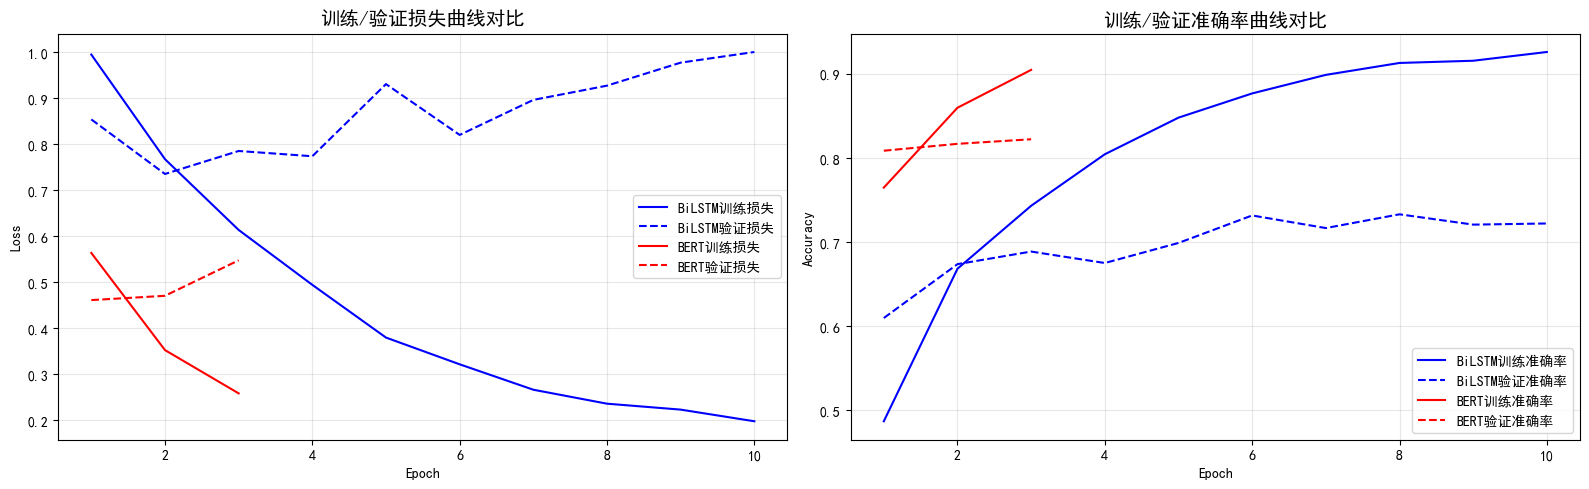

In [19]:
# ====== 训练曲线对比 ======
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

epochs_bi = range(1, len(bilstm_history['train_loss'])+1)
epochs_bert = range(1, len(bert_history['train_loss'])+1)

axes[0].plot(epochs_bi, bilstm_history['train_loss'], 'b-', label='BiLSTM训练损失')
axes[0].plot(epochs_bi, bilstm_history['val_loss'], 'b--', label='BiLSTM验证损失')
axes[0].plot(epochs_bert, bert_history['train_loss'], 'r-', label='BERT训练损失')
axes[0].plot(epochs_bert, bert_history['val_loss'], 'r--', label='BERT验证损失')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('训练/验证损失曲线对比', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_bi, bilstm_history['train_acc'], 'b-', label='BiLSTM训练准确率')
axes[1].plot(epochs_bi, bilstm_history['val_acc'], 'b--', label='BiLSTM验证准确率')
axes[1].plot(epochs_bert, [a for a in bert_history['train_acc']], 'r-', label='BERT训练准确率')
axes[1].plot(epochs_bert, bert_history['val_acc'], 'r--', label='BERT验证准确率')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('训练/验证准确率曲线对比', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 6.4 模型性能评估和可视化分析
  
- 两个模型的验证集评估表格

In [25]:
# ====== 加载最佳模型并评估 ======
# BiLSTM评估
bilstm_model.load_state_dict(torch.load('best_bilstm.pth', weights_only=True))
bilstm_model.eval()
bilstm_preds, bilstm_true = [], []
with torch.no_grad():
    for seqs, labels in val_loader:
        seqs = seqs.to(device)
        outputs = bilstm_model(seqs)
        bilstm_preds.extend(outputs.argmax(1).cpu().numpy())
        bilstm_true.extend(labels.numpy())

bilstm_preds = np.array(bilstm_preds)
bilstm_true = np.array(bilstm_true)

# BERT评估
bert_model.load_state_dict(torch.load('best_bert_model.pth', weights_only=True))
bert_model.eval()
bert_preds, bert_true = [], []
with torch.no_grad():
    for batch in bert_val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels']
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        bert_preds.extend(outputs.logits.argmax(1).cpu().numpy())
        bert_true.extend(labels.numpy())

bert_preds = np.array(bert_preds)
bert_true = np.array(bert_true)

# 打印评估报告
print("=" * 60)
print("BiLSTM 验证集评估报告:")
print("=" * 60)
print(classification_report(bilstm_true, bilstm_preds, target_names=[label_map[i] for i in [0,1,2]]))

print("=" * 60)
print("BERT 验证集评估报告:")
print("=" * 60)
print(classification_report(bert_true, bert_preds, target_names=[label_map[i] for i in [0,1,2]]))

BiLSTM 验证集评估报告:
              precision    recall  f1-score   support

          负面       0.49      0.41      0.45       153
          中性       0.70      0.85      0.77       729
          正面       0.85      0.68      0.75       586

    accuracy                           0.73      1468
   macro avg       0.68      0.64      0.66      1468
weighted avg       0.74      0.73      0.73      1468

BERT 验证集评估报告:
              precision    recall  f1-score   support

          负面       0.54      0.73      0.62       153
          中性       0.87      0.80      0.83       729
          正面       0.87      0.88      0.88       586

    accuracy                           0.82      1468
   macro avg       0.76      0.80      0.77      1468
weighted avg       0.83      0.82      0.83      1468



展示 BiLSTM 和 BERT 两个模型在验证集上的分类报告，包含各类别的精确率、召回率和 F1 值。BiLSTM 整体准确率 0.73，中性类别表现最好（F1=0.77），负面类别最弱（F1=0.45），主要问题是召回率低（0.41），大量负面样本被误判为其他类别。BERT 整体准确率 0.82，各类别指标均有明显提升，负面类别召回率从 0.41 跃升至 0.73，正面类别 F1 达到 0.88，宏平均 F1 从 0.66 提升至 0.77，说明 BERT 在少数类识别和整体均衡性上都优于 BiLSTM。

-  分类报告（精确率、召回率、F1）和各类别指标柱状图对比

模型性能对比汇总表格


,指标,BiLSTM,BERT
0,准确率,0.7330,0.8222
1,宏平均精确率,0.6833,0.7583
2,宏平均召回率,0.6446,0.8005
3,宏平均F1,0.6572,0.7742
4,加权平均F1,0.7296,0.8260


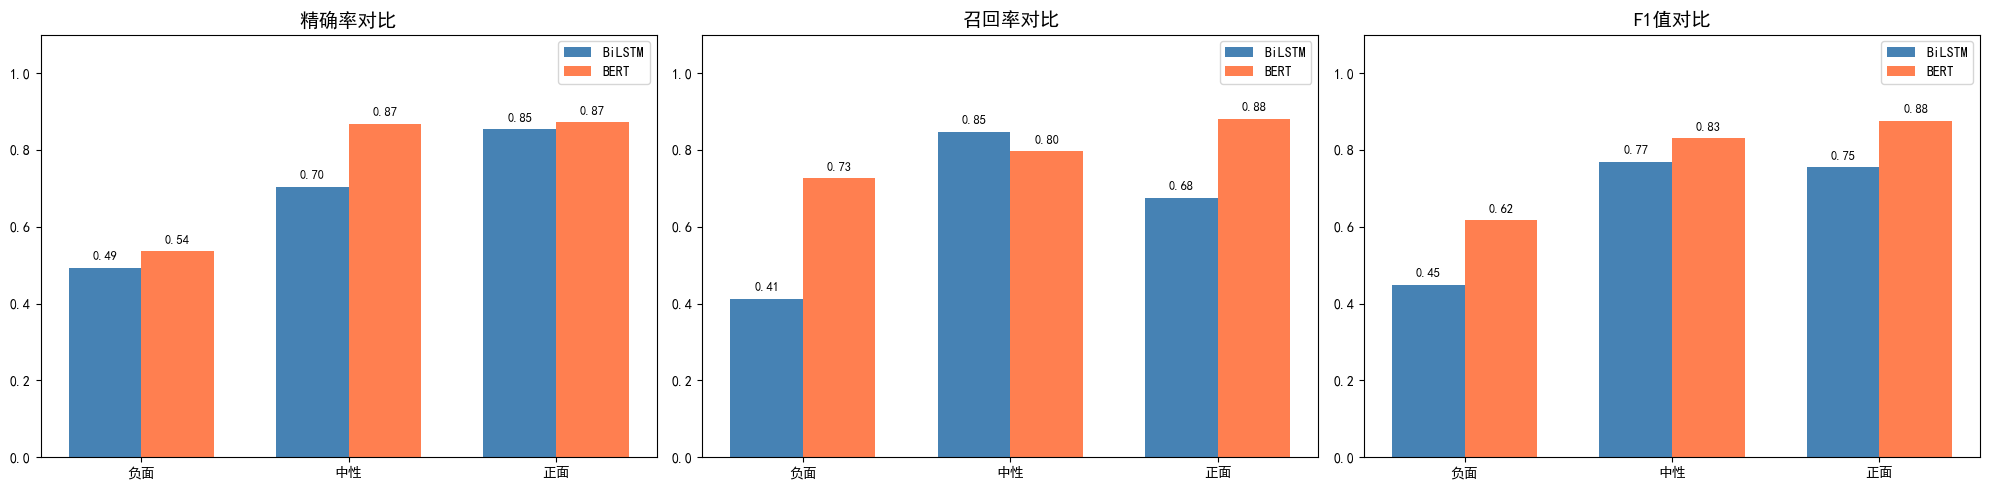

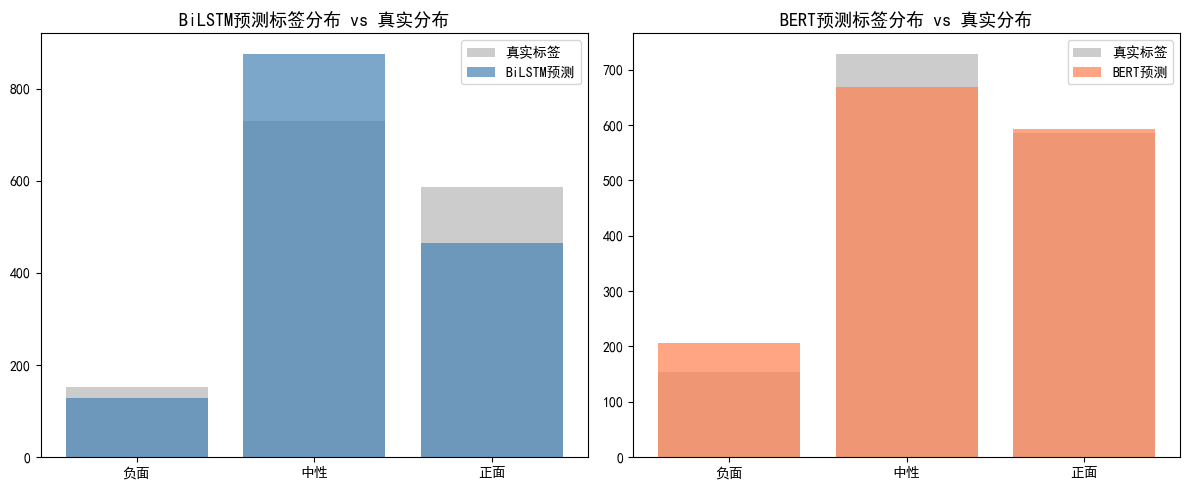

In [21]:
from sklearn.metrics import precision_score, recall_score

# ====== 汇总对比表格 ======
bi_acc = accuracy_score(bilstm_true, bilstm_preds)
bi_f1_macro = f1_score(bilstm_true, bilstm_preds, average='macro')
bi_f1_weighted = f1_score(bilstm_true, bilstm_preds, average='weighted')
bi_precision = precision_score(bilstm_true, bilstm_preds, average='macro')
bi_recall = recall_score(bilstm_true, bilstm_preds, average='macro')

bert_acc = accuracy_score(bert_true, bert_preds)
bert_f1_macro = f1_score(bert_true, bert_preds, average='macro')
bert_f1_weighted = f1_score(bert_true, bert_preds, average='weighted')
bert_precision = precision_score(bert_true, bert_preds, average='macro')
bert_recall = recall_score(bert_true, bert_preds, average='macro')

summary = pd.DataFrame({
    '指标': ['准确率', '宏平均精确率', '宏平均召回率', '宏平均F1', '加权平均F1'],
    'BiLSTM': [f'{bi_acc:.4f}', f'{bi_precision:.4f}', f'{bi_recall:.4f}', f'{bi_f1_macro:.4f}', f'{bi_f1_weighted:.4f}'],
    'BERT': [f'{bert_acc:.4f}', f'{bert_precision:.4f}', f'{bert_recall:.4f}', f'{bert_f1_macro:.4f}', f'{bert_f1_weighted:.4f}']
})
print("=" * 50)
print("模型性能对比汇总表格")
print("=" * 50)
display(summary)

# ====== 各类别指标柱状图对比 ======
bi_report = classification_report(bilstm_true, bilstm_preds, output_dict=True, target_names=[label_map[i] for i in [0,1,2]])
bert_report = classification_report(bert_true, bert_preds, output_dict=True, target_names=[label_map[i] for i in [0,1,2]])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
metrics = ['precision', 'recall', 'f1-score']
metric_names = ['精确率', '召回率', 'F1值']

for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
    bi_vals = [bi_report[label_map[i]][metric] for i in [0,1,2]]
    bert_vals = [bert_report[label_map[i]][metric] for i in [0,1,2]]
    x = np.arange(3)
    w = 0.35
    axes[idx].bar(x - w/2, bi_vals, w, label='BiLSTM', color='steelblue')
    axes[idx].bar(x + w/2, bert_vals, w, label='BERT', color='coral')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels([label_map[i] for i in [0,1,2]])
    axes[idx].set_title(f'{name}对比', fontsize=14)
    axes[idx].set_ylim(0, 1.1)
    axes[idx].legend()
    for j, (bv, brv) in enumerate(zip(bi_vals, bert_vals)):
        axes[idx].text(j - w/2, bv + 0.02, f'{bv:.2f}', ha='center', fontsize=9)
        axes[idx].text(j + w/2, brv + 0.02, f'{brv:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ====== 预测标签分布对比 ======
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bi_dist = pd.Series(bilstm_preds).value_counts().sort_index()
bert_dist = pd.Series(bert_preds).value_counts().sort_index()
true_dist_val = pd.Series(bilstm_true).value_counts().sort_index()

x = np.arange(3)
labels_x = [label_map[i] for i in [0,1,2]]
axes[0].bar(x, true_dist_val.values, alpha=0.4, label='真实标签', color='gray')
axes[0].bar(x, bi_dist.reindex([0,1,2], fill_value=0).values, alpha=0.7, label='BiLSTM预测', color='steelblue')
axes[0].set_title('BiLSTM预测标签分布 vs 真实分布', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_x)
axes[0].legend()

axes[1].bar(x, true_dist_val.values, alpha=0.4, label='真实标签', color='gray')
axes[1].bar(x, bert_dist.reindex([0,1,2], fill_value=0).values, alpha=0.7, label='BERT预测', color='coral')
axes[1].set_title('BERT预测标签分布 vs 真实分布', fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_x)
axes[1].legend()
plt.tight_layout()
plt.show()

计算并汇总 BiLSTM 和 BERT 的各项性能指标，生成对比表格和可视化图表。从汇总表格来看，BERT 在所有指标上均优于 BiLSTM：准确率从 0.7330 提升至 0.8222，宏平均 F1 从 0.6572 提升至 0.7742，加权平均 F1 从 0.7296 提升至 0.8260。各类别指标柱状图显示，BERT 在负面类别上的提升最为显著，精确率从 0.49 提升至 0.54，召回率从 0.41 提升至 0.73，F1 从 0.45 提升至 0.62；正面类别也从中性提升至较高水平（F1 从 0.75 提升至 0.88）。预测标签分布对比图进一步展示了两个模型的预测偏好：BiLSTM 倾向于将更多样本预测为中性和正面，负面类别预测数量明显不足；BERT 的预测分布更接近真实标签分布，尤其在负面和正面类别上的预测数量更合理，体现了更强的类别均衡识别能力。


- 混淆矩阵热力图

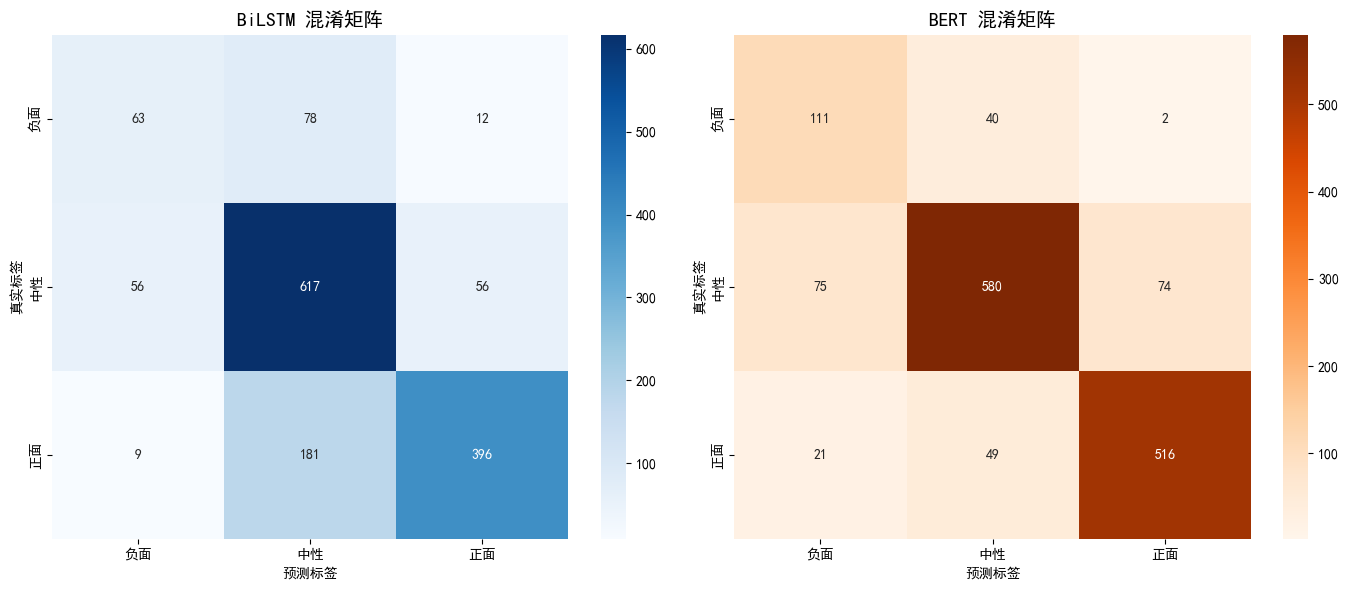

In [22]:
# ====== 混淆矩阵对比 ======
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_bi = confusion_matrix(bilstm_true, bilstm_preds)
cm_bert = confusion_matrix(bert_true, bert_preds)

sns.heatmap(cm_bi, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[label_map[i] for i in [0,1,2]],
            yticklabels=[label_map[i] for i in [0,1,2]])
axes[0].set_title('BiLSTM 混淆矩阵', fontsize=14)
axes[0].set_xlabel('预测标签')
axes[0].set_ylabel('真实标签')

sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=[label_map[i] for i in [0,1,2]],
            yticklabels=[label_map[i] for i in [0,1,2]])
axes[1].set_title('BERT 混淆矩阵', fontsize=14)
axes[1].set_xlabel('预测标签')
axes[1].set_ylabel('真实标签')

plt.tight_layout()
plt.show()

绘制 BiLSTM 和 BERT 两个模型的混淆矩阵热力图，直观展示各类别的分类情况。从 BiLSTM 的混淆矩阵来看，中性类别（617/729）识别较为准确，但负面类别仅有 63/153 被正确预测，大量负面样本被误判为中性（78 条）或正面（12 条），说明 BiLSTM 对少数类的区分能力较弱。BERT 的混淆矩阵整体表现更好，负面类别正确预测数从 63 提升至 111，中性类别 580/729 正确，正面类别 516/586 正确，对角线上的数值普遍更高，非对角线上的误判数量明显减少。两个模型的混淆矩阵均显示中性类别的识别效果最好，这与中性样本数量最多、特征较明显有关。

- 错误样本分析  


In [24]:
# ====== 错误样本分析 ======
print("===== BiLSTM 错误分类样本示例 =====")
bi_wrong = np.where(bilstm_preds != bilstm_true)[0]
for i in bi_wrong[:5]:
    true_label = label_map[bilstm_true[i]]
    pred_label = label_map[bilstm_preds[i]]
    print(f"  真实:{true_label} → 预测:{pred_label}")

print(f"\nBiLSTM错误数: {len(bi_wrong)}/{len(bilstm_true)} ({len(bi_wrong)/len(bilstm_true)*100:.1f}%)")

print("\n===== BERT 错误分类样本示例 =====")
bert_wrong = np.where(bert_preds != bert_true)[0]
for i in bert_wrong[:5]:
    true_label = label_map[bert_true[i]]
    pred_label = label_map[bert_preds[i]]
    print(f"  真实:{true_label} → 预测:{pred_label}")

print(f"\nBERT错误数: {len(bert_wrong)}/{len(bert_true)} ({len(bert_wrong)/len(bert_true)*100:.1f}%)")

# 两个模型共同错误 vs 各自独有错误
bi_wrong_set = set(bi_wrong.tolist())
bert_wrong_set = set(bert_wrong.tolist())
both_wrong = bi_wrong_set & bert_wrong_set
bi_only = bi_wrong_set - bert_wrong_set
bert_only = bert_wrong_set - bi_wrong_set
print(f"\n两模型共同分错: {len(both_wrong)}条")
print(f"仅BiLSTM分错: {len(bi_only)}条")
print(f"仅BERT分错: {len(bert_only)}条")

===== BiLSTM 错误分类样本示例 =====
  真实:正面 → 预测:中性
  真实:正面 → 预测:中性
  真实:负面 → 预测:中性
  真实:中性 → 预测:负面
  真实:负面 → 预测:中性

BiLSTM错误数: 392/1468 (26.7%)

===== BERT 错误分类样本示例 =====
  真实:正面 → 预测:中性
  真实:中性 → 预测:正面
  真实:负面 → 预测:中性
  真实:中性 → 预测:正面
  真实:中性 → 预测:负面

BERT错误数: 261/1468 (17.8%)

两模型共同分错: 138条
仅BiLSTM分错: 254条
仅BERT分错: 123条


对两个模型的错误分类样本进行分析。BiLSTM 共误判 392 条（26.7%），BERT 误判 261 条（17.8%），BERT 的错误率明显更低。从错误样本示例来看，BiLSTM 的主要问题是大量负面和正面样本被误判为中性，反映出模型对情感极性较弱样本的区分能力不足。BERT 虽然也存在中性与正面/负面之间的混淆，但误判数量较少。进一步对比两个模型的错误重叠情况：共同分错 138 条，这些样本本身语义模糊、分类难度较高；仅 BiLSTM 分错 254 条，说明有相当一部分样本 BERT 能做对而 BiLSTM 做不对；仅 BERT 分错 123 条，表明 BERT 也存在少量自身的薄弱环节。总体而言，BERT 在错误数量和分类均衡性上均优于 BiLSTM。



- 综合指标雷达图和预测标签分布对比

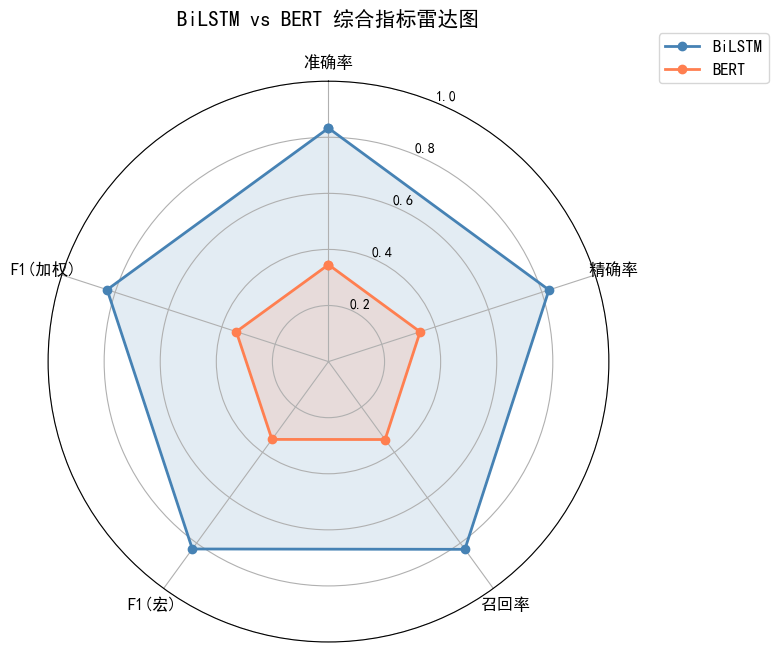

测试集预测结果已保存到 test_predictions.csv

测试集预测分布:
BiLSTM: {0: 913, 1: 3714, 2: 2729}
BERT:   {0: 1160, 1: 3177, 2: 3019}

预测结果前10条:


,id,title,BiLSTM预测,BiLSTM情感,BERT预测,BERT情感
0,00005a3efe934a19adc0b69b05faeae7,九江办好人民满意教育,0,负面,0,负面
1,0009dc82c41341d794837271d4dbff5f,中央第三生态环境保护督察组转办我市第三十一批信访件办理情况,1,中性,1,中性
2,000f3763b6074588817c9ab90a22a814,大雨天车被淹，保险公司该不该赔？,1,中性,1,中性
3,00117934dbe240068c95b6d04b08eea7,英特尔新cpu微架构ocean cove曝光,2,正面,1,中性
4,0014cef5ccfa43b3a6b20162a03763fa,公安部侦破一批重大网络赌博案件 德州约局平台成重灾区,1,中性,0,负面
5,0015fb20dbd54d249a50559789f43c52,广西龙胜千层天梯闹春耕,0,负面,0,负面
6,002a0b77fded4ae1abaa8ed9f2ad0824,高唐小伙:挺身而出救交警,0,负面,0,负面
7,002c023ddb7343fdb8b3652ace2ded15,东营共享单车远走青岛，中间到底发生了什么?,1,中性,1,中性
8,002daa98e1b240679212a1b7a0402996,已有19人被捕!你的老婆可能还在做…赶紧看!,1,中性,1,中性
9,00305089bee5422ca2423176c448e91a,这两名“飙车党”太猖狂，竟当着重庆民警面玩漂移,2,正面,2,正面


In [ ]:
# ====== 综合指标雷达图 ======
from math import pi

categories = ['准确率', '精确率', '召回率', 'F1(宏)', 'F1(加权)']
bi_values = [bi_acc, bi_precision, bi_recall, bi_f1_macro, bi_f1_weighted]
bert_values = [bert_acc, bert_precision, bert_recall, bert_f1_macro, bert_f1_weighted]

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]
bi_values += bi_values[:1]
bert_values += bert_values[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)

ax.plot(angles, bi_values, 'o-', linewidth=2, label='BiLSTM', color='steelblue')
ax.fill(angles, bi_values, alpha=0.15, color='steelblue')
ax.plot(angles, bert_values, 'o-', linewidth=2, label='BERT', color='coral')
ax.fill(angles, bert_values, alpha=0.15, color='coral')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_title('BiLSTM vs BERT 综合指标雷达图', fontsize=15, pad=20)
plt.tight_layout()
plt.show()

# ====== 测试集预测（BiLSTM） ======
bilstm_model.eval()
test_preds_bi = []
with torch.no_grad():
    for seqs in test_loader:
        if isinstance(seqs, (list, tuple)):
            seqs = seqs[0]
        seqs = seqs.to(device)
        outputs = bilstm_model(seqs)
        test_preds_bi.extend(outputs.argmax(1).cpu().numpy())

# 测试集预测（BERT）
bert_model.eval()
test_preds_bert = []
with torch.no_grad():
    for batch in bert_test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        test_preds_bert.extend(outputs.logits.argmax(1).cpu().numpy())

# 保存结果
test_data['BiLSTM预测'] = test_preds_bi
test_data['BERT预测'] = test_preds_bert
test_data['BiLSTM情感'] = test_data['BiLSTM预测'].map(label_map)
test_data['BERT情感'] = test_data['BERT预测'].map(label_map)

result = test_data[['id', 'title', 'BiLSTM预测', 'BiLSTM情感', 'BERT预测', 'BERT情感']]
result.to_csv('test_predictions.csv', index=False, encoding='utf-8-sig')

print("测试集预测结果已保存到 test_predictions.csv")
print(f"\n测试集预测分布:")
print(f"BiLSTM: {pd.Series(test_preds_bi).value_counts().sort_index().to_dict()}")
print(f"BERT:   {pd.Series(test_preds_bert).value_counts().sort_index().to_dict()}")
print("\n预测结果前10条:")
display(result.head(10))

绘制 BiLSTM 与 BERT 的综合指标雷达图，从准确率、精确率、召回率、宏平均 F1 和加权平均 F1 五个维度进行直观对比。雷达图显示 BERT 在各个维度上的覆盖面积均大于 BiLSTM，整体表现更均衡。随后使用两个模型对测试集（7356 条）进行预测，并将结果保存至 test_predictions.csv。从预测分布来看，BiLSTM 预测负面 913 条、中性 3714 条、正面 2729 条；BERT 预测负面 1160 条、中性 3177 条、正面 3019 条。BERT 的负面预测数量更多，中性预测更少，说明 BERT 对负面样本的识别能力更强，预测分布更接近真实分布。部分测试样本的预测示例展示了两个模型在同一文本上的判断差异，例如对于"公安部侦破一批重大网络赌博案件"，BiLSTM 判为中性而 BERT 判为负面，BERT 对负面语义的理解更准确

## 七、总结

本课程设计基于 PyTorch 框架，分别构建了 BiLSTM 和 BERT 两个模型对中文新闻文本进行三分类情感分析实验。主要结论如下：

  1.数据层面：通过 jieba 分词、文本清洗和过采样数据增强，将训练集从 5872 条扩充至 8751 条，有效缓解了类别不平衡问题。

  2.模型表现：BiLSTM 验证集准确率为 73.30%，BERT 验证集准确率为 82.22%，BERT 在准确率、精确率、召回率和 F1 值等所有指标上均优于 BiLSTM，尤其在负面类别的识别上提升最为显著（召回率从 0.41 提升至 0.73）。

  3.训练过程：BiLSTM 训练 10 轮后出现明显过拟合（训练准确率 0.93 vs 验证准确率 0.73）；BERT 采用层冻结策略仅训练最后 2 层编码器，3 轮即达到较好效果，收敛速度更快且过拟合程度较轻。

  4.错误分析：两模型共同分错 138 条样本，这些样本多为语义模糊、情感倾向不明显的短文本；BiLSTM 独有的 254 条错误中，大量为正面/负面被误判为中性的情况，反映出模型对情感极性的区分能力不足。
  
  5.原因分析：BERT 基于 Transformer 自注意力机制和大规模预训练语料，能够更好地理解中文语境和长距离语义关系；BiLSTM 虽能捕捉序列依赖，但受限于词汇表规模和模型容量，对复杂语义的理解能力较弱。

综上所述，BERT 在中文文本情感分析任务中具有明显优势，适合作为该任务的最终模型；BiLSTM 作为轻量级基线模型，在资源有限的场景下仍具有一定参考价值。